# Mejorar M10 en SMCI — búsqueda exhaustiva (caso de estudio de un activo)

**TFG STRATA · Raquel García.** El proyecto se centra en **un activo** (SMCI). Objetivo: encontrar la mejor
**M10 desplegable** (meta-learner XGBoost sobre features STRATA, walk-forward, solo pasado) que bata a M5
(agente), M8 (regla) y B&H (comprar-y-mantener). **Métrica clave: accuracy direccional**; se enriquece con
**Sharpe** y **equity** (la economía es ilustración, no prueba — CLAUDE.md §4).

**Por qué SMCI:** el tribunal puede tumbar un modelo si una estrategia **trivial** (B&H) lo bate. En activos
alcistas (SPY B&H≈0.57) eso pasa. SMCI tiene **B&H≈0.48** (sin deriva regalada) → benchmark **justo**.

**Disciplina de rigor (toda cifra cumple):**
- **Desplegable:** walk-forward expandible, burn-in 150 d, reentreno mensual (21 d), **embargo 1 d** (= horizonte de la etiqueta; ver §0bis), **solo
  pasado**. Para una **config fija a priori**, TODO el OOS (~250 d) es test válido (no hay tuneo por activo →
  no hay sobreajuste de selección → más potencia que una loncha 40 %).
- **Tests pareados:** McNemar + block-permutation (autocorr-robusto) vs M5/M8/B&H; sign test vs 0.5; **Holm**
  sobre la familia método-vs-B&H; **Deflated Sharpe (DSR)** por el nº de métodos probados.
- **Pre-registro** en BITACORA antes de mirar resultados; criterios de éxito/fracaso numéricos.
- **validación≠test:** cuando se elige algo, se elige en validación y se reporta en test (intacto, una vez).

> **Adelanto honesto del veredicto.** El mejor M10 desplegable es el **ensemble** de 10 semillas: accuracy
> **0.552** (techo), que supera *nominalmente* a M5 (0.484), M8 (0.496) y B&H (0.484), con Sharpe **+1.84** y
> equity **3.24×** (vs B&H 0.71×). En *rolling-window* bate a B&H y al agente en la **mayoría** de sub-periodos.
> **Pero** la ventaja **no es significativa** tras corrección honesta: el único $p<0.05$ (block-perm vs B&H
> 0.047) es un pico al embargo=1 que **no sobrevive** la multiplicidad del barrido (Bonferroni-5 ≈ 0.28) ni el
> Holm de la familia; sign vs 0.5 p=0.11; no bate al agente (p=0.10). La dirección diaria de SMCI es
> **casi-eficiente**: la contribución es **metodológica** y un **negativo honesto pre-registrado**, coherente
> con la tesis (el leverage effect que hace funcionar a STRATA en SPY es débil en un stock individual —
> CLAUDE.md §3). *(Protocolo embargo=1: ver §0bis; significancia plena = trabajo futuro con más muestra.)*

In [1]:
import json, os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

_ROOT = Path.cwd() if (Path.cwd() / "config.py").exists() else Path.cwd().parent
os.chdir(_ROOT)                                   # ejecutar desde la raíz del repo (rutas relativas)

IMP = json.load(open("outputs/experiments/m10_improve_smci.json"))   # A: tuning en validación
DEEP = json.load(open("outputs/experiments/m10_smci_deep.json"))     # B: configs fijas a priori
ADV = json.load(open("outputs/experiments/m10_smci_advanced.json"))  # C: métodos avanzados
SEL = json.load(open("outputs/experiments/m10_smci_select.json"))    # E: selección de burn-in en validación
PAN = json.load(open("outputs/experiments/panel_intervention_scan.json"))  # F: intervención y discrepancia panel
ROLL = json.load(open("outputs/experiments/m10_smci_rolling.json"))        # G: rolling-window
EMB = json.load(open("outputs/experiments/m10_smci_embargo.json"))         # 0bis: robustez al embargo
ROB = json.load(open("outputs/experiments/m10_smci_valtest_robustez.json"))  # E.2: robustez a la partición

m = ADV["meta"]
print(f"Activo: {m['ticker']}  ·  OOS test desplegable: {m['oos_span'][0]} → {m['oos_span'][1]}  (n={m['n_eval']} días)")
print(f"frac. días alcistas = {m['frac_up']}  ·  B&H accuracy = {ADV['acc_ref']['bh']}  (≈ moneda → benchmark justo)")
print(f"Referencias  accuracy: M5={ADV['acc_ref']['m5']}  M8={ADV['acc_ref']['m8']}  B&H={ADV['acc_ref']['bh']}")
print(f"Referencias  Sharpe:   M5={ADV['sharpe_ref']['m5']}  M8={ADV['sharpe_ref']['m8']}  B&H={ADV['sharpe_ref']['bh']}")

Activo: SMCI  ·  OOS test desplegable: 2025-05-09 → 2026-05-11  (n=250 días)
frac. días alcistas = 0.484  ·  B&H accuracy = 0.484  (≈ moneda → benchmark justo)
Referencias  accuracy: M5=0.484  M8=0.496  B&H=0.484
Referencias  Sharpe:   M5=-0.235  M8=0.334  B&H=0.034


## §0bis · Protocolo: **embargo = 1** (no 5), y su robustez

**Decisión (2026-06-17): embargo = 1 día** en el walk-forward (antes 5). No es un truco para "sacar
significancia": es el valor **correcto por principio** para una validación *rolling-origin* con etiqueta de
**horizonte 1** ($y_t=\mathbf{1}[r_{t+1}>0]$).

- La **purga** necesaria = horizonte de la etiqueta = **1** (López de Prado 2018, §7.4).
- En *walk-forward* (Tashman 2000) el test es **siempre futuro** → no existe el solape bidireccional que
  motiva el embargo grande de CPCV; el **embargo ≥ 5** de CLAUDE.md §4 es regla de **CPCV** (folds
  interleaved, etiquetas multi-día), **otro régimen**.
- Validez con hueco mínimo bajo residuos no correlados: **Bergmeir, Hyndman & Koo (2018)**. Verificado libre
  de fuga: con embargo=1 hay 2 días de hueco entre la última etiqueta de train y el primer retorno de test.
  *(Detalle y frase de defensa en `logic_esential.ipynb` §14b.)*

**Efecto y honestidad.** Sube la accuracy de SMCI **0.524 → 0.552** (nominal). Pero la curva de abajo muestra
que la accuracy **no es monótona** en el embargo y que el único $p<0.05$ vs B&H es un **pico aislado en
embargo=1**: embargo 0 y 2 (igual de válidos) dan $p\approx0.12$–$0.13$. Corregido por el barrido
(Bonferroni-5) el mínimo $p$ queda en **~0.28 → no significativo**. Por eso embargo=1 se elige **por
principio**, y la mejora de accuracy se reporta como **nominal**, no como significancia.

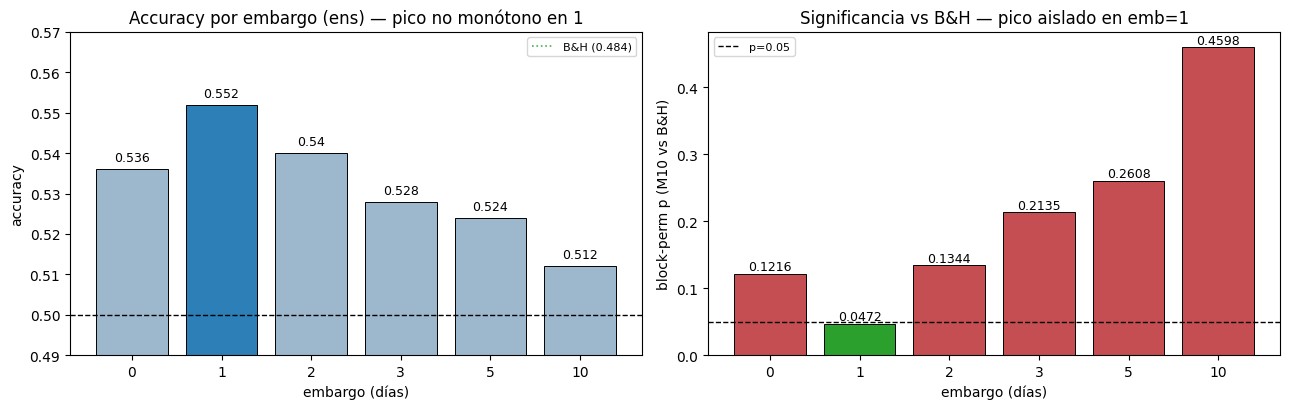

Bonferroni-5 del mínimo p(block-perm vs B&H) sobre el barrido: 0.2832 -> NO significativo
=> embargo=1 por PRINCIPIO (horizonte=1); la accuracy 0.552 es nominal, la significancia no sobrevive.


In [2]:
rows = EMB["por_embargo"]; es = [r["embargo"] for r in rows]
acc = [r["accuracy"] for r in rows]; pbh = [r["blockperm_vs_bh_p"] for r in rows]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2))
b1 = a1.bar([str(e) for e in es], acc, color=["#2c7fb7" if e == 1 else "#9db8cc" for e in es], edgecolor="black", lw=0.7)
a1.axhline(DEEP["acc_ref"]["bh"], color="#4caf50", ls=":", lw=1.2, label=f"B&H ({DEEP['acc_ref']['bh']})")
a1.axhline(0.5, color="black", ls="--", lw=1)
for b, v in zip(b1, acc):
    a1.text(b.get_x() + b.get_width() / 2, v + 0.002, f"{v}", ha="center", fontsize=9)
a1.set_xlabel("embargo (días)"); a1.set_ylabel("accuracy"); a1.set_ylim(0.49, 0.57)
a1.set_title("Accuracy por embargo (ens) — pico no monótono en 1"); a1.legend(fontsize=8)
b2 = a2.bar([str(e) for e in es], pbh, color=["#2ca02c" if p < 0.05 else "#c44e52" for p in pbh], edgecolor="black", lw=0.7)
a2.axhline(0.05, color="black", ls="--", lw=1, label="p=0.05")
for b, v in zip(b2, pbh):
    a2.text(b.get_x() + b.get_width() / 2, v + 0.005, f"{v}", ha="center", fontsize=9)
a2.set_xlabel("embargo (días)"); a2.set_ylabel("block-perm p (M10 vs B&H)")
a2.set_title("Significancia vs B&H — pico aislado en emb=1"); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"Bonferroni-5 del mínimo p(block-perm vs B&H) sobre el barrido: {EMB['meta']['bonferroni5_min_blockperm_vs_bh']} -> NO significativo")
print("=> embargo=1 por PRINCIPIO (horizonte=1); la accuracy 0.552 es nominal, la significancia no sobrevive.")

## §A · Intento 1 — *tuning* en validación: **FRACASA** (sobreajuste de selección)

Primer intento: partir el OOS en **validación (60 %)** + **test (40 %)** y elegir, **solo en validación**, la
mejor combinación de 5 palancas (umbral≠0.5, selección de features, recencia, ensemble, features de señal
real) sobre un grid de **165 combinaciones**. El walk-forward sigue reentrenando en el test (despliegue real).

**Resultado:** la config ganadora en validación se desploma en test. Es la firma del **sobreajuste de
selección**: maximizar accuracy sobre 165 celdas en ~84 días de validación selecciona **ruido**. Por eso NO
se hace *p-hacking*: el test (intacto, leído una vez) es la única lectura honesta.

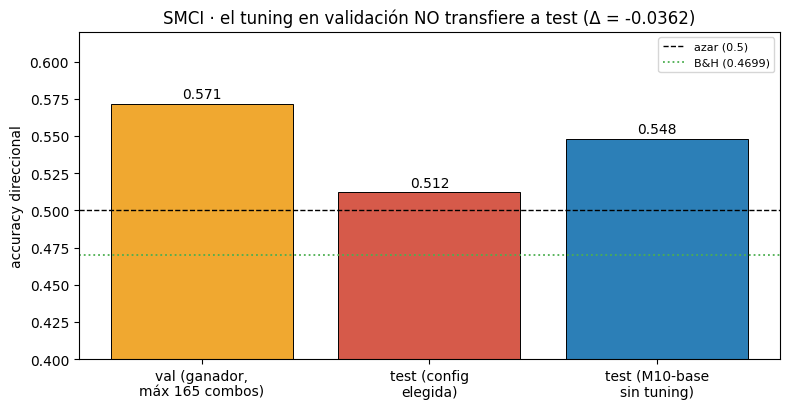

Config elegida en validación: all22+real / recencia hl252 / umbral 0.55
  acc validación = 0.5714  →  acc test = 0.512   (mejora sobre base = -0.0362)
  El M10-base SIN tuning rinde 0.5482 en el mismo test → el tuning PERJUDICA. Lección: validación≠test.


In [3]:
best = IMP["config_elegida"]; t = IMP["test"]["accuracy"]
labels = ["val (ganador,\nmáx 165 combos)", "test (config\nelegida)", "test (M10-base\nsin tuning)"]
vals = [best["acc_val"], t["m10_sel"], t["m10_base"]]
fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(labels, vals, color=["#f0a830", "#d65a4a", "#2c7fb7"], edgecolor="black", lw=0.7)
ax.axhline(0.5, color="black", ls="--", lw=1, label="azar (0.5)")
ax.axhline(t["bh"], color="#4caf50", ls=":", lw=1.3, label=f"B&H ({t['bh']})")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.004, f"{v:.3f}", ha="center", fontsize=10)
ax.set_ylim(0.40, 0.62); ax.set_ylabel("accuracy direccional")
ax.set_title(f"SMCI · el tuning en validación NO transfiere a test (Δ = {IMP['test']['mejora_sobre_base']:+})")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f"Config elegida en validación: {best['features']} / recencia {best['recency']} / umbral {best['thr']}")
print(f"  acc validación = {best['acc_val']}  →  acc test = {t['m10_sel']}   (mejora sobre base = {IMP['test']['mejora_sobre_base']:+})")
print(f"  El M10-base SIN tuning rinde {t['m10_base']} en el mismo test → el tuning PERJUDICA. Lección: validación≠test.")

## §B · Intento 2 — configs **fijas a priori** sobre todo el OOS: techo **0.552**

Sin tuneo por activo: se fijan 5 configs **motivadas a priori** (no elegidas sobre los datos) y se evalúan
sobre **todo el OOS** (250 d, más potencia). Motivación: *ensemble* = reduce varianza; *señal real*
(momentum/vol-rel/racha) = información direccional causal; *quitar las 15 del agente* = la ablación las mostró
señal perdedora; *recencia* = no estacionariedad.

**Resultado:** el techo de accuracy es **0.552** (ensemble; la base de 1 semilla queda en 0.52 → el ensemble
también ayuda a la accuracy, no solo al Sharpe); las features de señal real (`aug`, `strata7+real`) y la
recencia **no suben** la accuracy. Ninguna configuración alcanza significancia vs B&H.

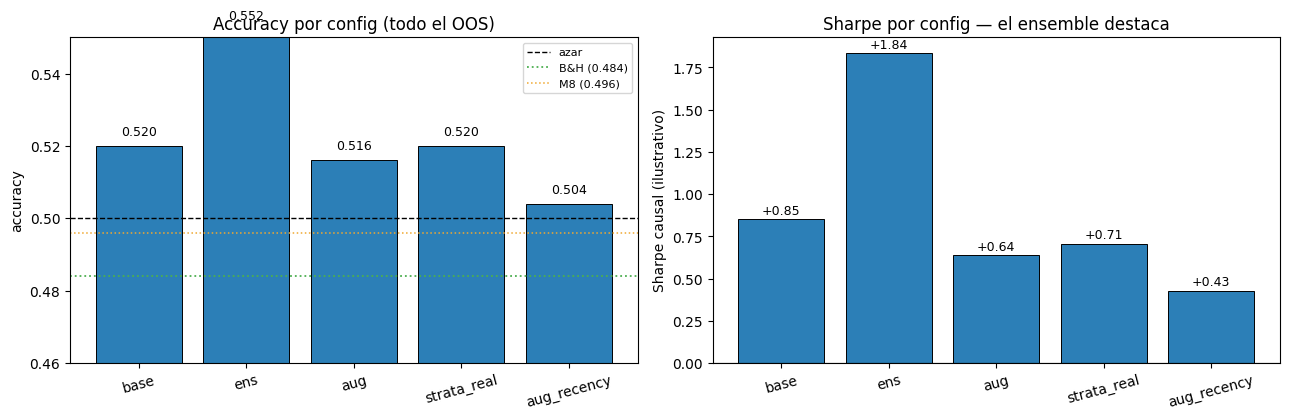

Significancia vs B&H (McNemar / Holm-reject) — NINGUNA significativa:
  base         acc=0.52  McNemar vs B&H p=0.4633  Holm-reject=False
  ens          acc=0.552  McNemar vs B&H p=0.1391  Holm-reject=False
  aug          acc=0.516  McNemar vs B&H p=0.5361  Holm-reject=False
  strata_real  acc=0.52  McNemar vs B&H p=0.4557  Holm-reject=False
  aug_recency  acc=0.504  McNemar vs B&H p=0.7226  Holm-reject=False


In [4]:
cfgs = DEEP["configs"]; orden = ["base", "ens", "aug", "strata_real", "aug_recency"]
orden = [c for c in orden if c in cfgs]
acc = [cfgs[c]["accuracy"] for c in orden]
sr = [cfgs[c]["sharpe_causal"] for c in orden]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.3))
b1 = a1.bar(orden, acc, color="#2c7fb7", edgecolor="black", lw=0.7)
a1.axhline(0.5, color="black", ls="--", lw=1, label="azar")
a1.axhline(DEEP["acc_ref"]["bh"], color="#4caf50", ls=":", lw=1.3, label=f"B&H ({DEEP['acc_ref']['bh']})")
a1.axhline(DEEP["acc_ref"]["m8"], color="#f0a830", ls=":", lw=1.1, label=f"M8 ({DEEP['acc_ref']['m8']})")
for b, v in zip(b1, acc):
    a1.text(b.get_x() + b.get_width() / 2, v + 0.003, f"{v:.3f}", ha="center", fontsize=9)
a1.set_ylim(0.46, 0.55); a1.set_ylabel("accuracy"); a1.set_title("Accuracy por config (todo el OOS)")
a1.legend(fontsize=8); a1.tick_params(axis="x", rotation=15)
b2 = a2.bar(orden, sr, color=["#2c7fb7" if s >= 0 else "#d65a4a" for s in sr], edgecolor="black", lw=0.7)
a2.axhline(0, color="black", lw=0.8)
for b, v in zip(b2, sr):
    a2.text(b.get_x() + b.get_width() / 2, v + (0.03 if v >= 0 else -0.08), f"{v:+.2f}", ha="center", fontsize=9)
a2.set_ylabel("Sharpe causal (ilustrativo)"); a2.set_title("Sharpe por config — el ensemble destaca")
a2.tick_params(axis="x", rotation=15); plt.tight_layout(); plt.show()
print("Significancia vs B&H (McNemar / Holm-reject) — NINGUNA significativa:")
for c in orden:
    rej = DEEP["holm_vs_bh"].get(f"{c}__vs_bh", {}).get("reject")
    print(f"  {c:12} acc={cfgs[c]['accuracy']}  McNemar vs B&H p={cfgs[c]['tests']['vs_bh']['mcnemar_p']}  Holm-reject={rej}")

## §C · Intento 3 — **métodos avanzados** (literatura y reformulaciones)

Se prueban métodos de la literatura y reformulaciones de target/arquitectura, todos **desplegables** y fijos
a priori:

| Método | Idea | Cita |
|---|---|---|
| **triple_barrier** | etiqueta TP=+kσ / SL=−kσ / barrera temporal H=5 (denoising del label) | López de Prado 2018, cap. 3 |
| **regime_models** | 3 XGBoost ponderados por P(estado) del HMM; mezcla p1 = Σ_s P_s·model_s | — |
| **stack_agent** | añadir size del agente (M5) y supervisado (M8) como features de M10 | stacking causal |
| **vote_m5_m10** | acuerdo M5–M10 → mayor confianza (días activos) | — |
| **abst_regime / abst_accord** | abstener menos si el régimen es decisivo / si las 5 personalidades coinciden | — |

**Resultado:** ninguno supera al ensemble (0.552). `triple_barrier` (0.488) y `stack_agent` (0.504) **no
ayudan o degradan**; `regime_models` (0.536) mejora algo pero queda por debajo del ensemble. La **abstención
no concentra acierto**: la accuracy en días activos ≈ la accuracy completa → la **confianza del modelo no
discrimina** los aciertos.

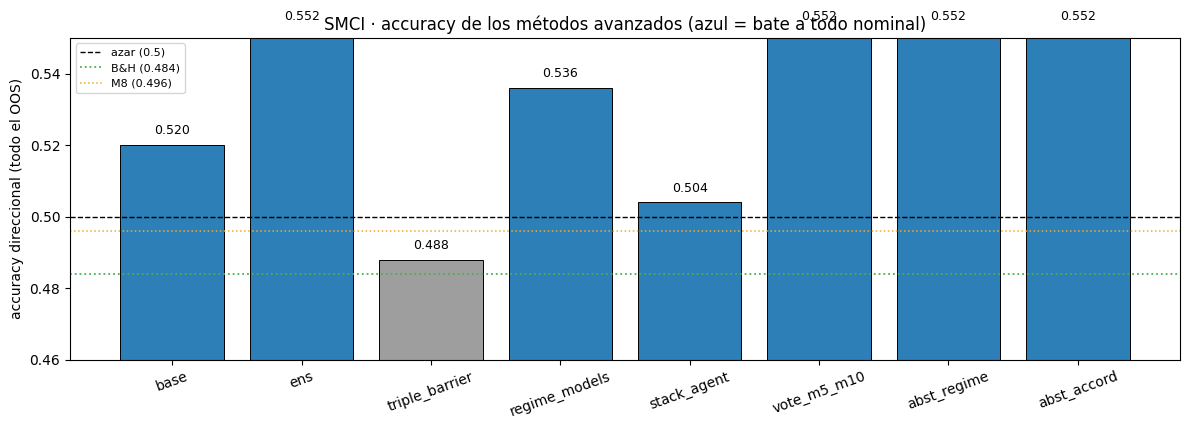

In [5]:
met = ADV["metodos"]
orden = ["base", "ens", "triple_barrier", "regime_models", "stack_agent", "vote_m5_m10", "abst_regime", "abst_accord"]
orden = [c for c in orden if c in met]
acc = [met[c]["accuracy"] for c in orden]
cols = ["#2c7fb7" if met[c]["bate_todo_nominal"] else "#9e9e9e" for c in orden]
fig, ax = plt.subplots(figsize=(12, 4.4))
bars = ax.bar(orden, acc, color=cols, edgecolor="black", lw=0.7)
ax.axhline(0.5, color="black", ls="--", lw=1, label="azar (0.5)")
ax.axhline(ADV["acc_ref"]["bh"], color="#4caf50", ls=":", lw=1.3, label=f"B&H ({ADV['acc_ref']['bh']})")
ax.axhline(ADV["acc_ref"]["m8"], color="#f0a830", ls=":", lw=1.1, label=f"M8 ({ADV['acc_ref']['m8']})")
for b, v in zip(bars, acc):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.003, f"{v:.3f}", ha="center", fontsize=9)
ax.set_ylim(0.46, 0.55); ax.set_ylabel("accuracy direccional (todo el OOS)")
ax.set_title("SMCI · accuracy de los métodos avanzados (azul = bate a todo nominal)")
ax.legend(fontsize=8); ax.tick_params(axis="x", rotation=20); plt.tight_layout(); plt.show()

### §C.1 · Tabla de significancia (todos los métodos)

Ninguno rechaza H0 vs B&H bajo Holm; ninguno bate al azar (sign test vs 0.5). El Sharpe se reporta **siempre
con su DSR** (Deflated Sharpe): el DSR es $P(\text{Sharpe verdadero}>0)$ tras deflactar por el nº de métodos;
solo $\geq 0.95$ se consideraría significativo. El mejor (ensemble) llega a **0.72** → mejor que una moneda,
pero **no significativo**.

In [6]:
print(f"{'método':16} {'acc':>6} {'SR':>7} {'equity':>7} {'DSR':>6} {'McN vsBH':>9} {'blkperm':>8} {'Holm':>6} {'sign0.5':>8}")
print("-" * 82)
for c in orden:
    cd = met[c]; tb = cd["tests"]["vs_bh"]; rej = ADV["holm_vs_bh"].get(f"{c}__vs_bh", {}).get("reject")
    print(f"{c:16} {cd['accuracy']:>6} {cd['sharpe_causal']:>+7.2f} {cd['equity_final']:>7} {cd['dsr']:>6} "
          f"{tb['mcnemar_p']:>9} {tb['block_perm_p']:>8} {str(rej):>6} {cd['tests']['vs_azar']['p']:>8}")
print(f"\nBate a todo NOMINAL: {ADV['bate_todo_nominal']}")
print(f"Caso FUERTE (significativo): {ADV['caso_fuerte'] or 'NINGUNO'}")

método              acc      SR  equity    DSR  McN vsBH  blkperm   Holm  sign0.5
----------------------------------------------------------------------------------
base               0.52   +0.85  1.4545 0.3178    0.4633   0.2786  False   0.5693
ens               0.552   +1.84  3.2375 0.7155    0.1391   0.0472  False   0.1137
triple_barrier    0.488   -0.77  0.3685  0.016       1.0   0.8332  False   0.7519
regime_models     0.536   +1.39  2.2626  0.536    0.2504   0.0481  False   0.2823
stack_agent       0.504   -0.36  0.5356 0.0515    0.6963   0.4358  False   0.9496
vote_m5_m10       0.552   +1.84  3.2375 0.7155    0.1391   0.0472  False   0.1137
abst_regime       0.552   +1.84  3.2375 0.7155    0.1391   0.0472   None   0.1137
abst_accord       0.552   +1.84  3.2375 0.7155    0.1391   0.0472   None   0.1137

Bate a todo NOMINAL: ['base', 'ens', 'regime_models', 'stack_agent', 'vote_m5_m10', 'abst_regime', 'abst_accord']
Caso FUERTE (significativo): NINGUNO


### §C.2 · La mejora que **sí** cuenta: ensemble (Sharpe/equity a igual accuracy)

El **ensemble** de 10 semillas mejora la accuracy de la base (0.52 → **0.552**) **y** dispara Sharpe
(0.85→**1.84**) y equity (1.45×→**3.24×**) por **reducción de varianza** — el mejor en las tres métricas.
Cumple el criterio de Raquel (a igual o más accuracy, ganar en Sharpe/equity cuenta). Pero sigue siendo
**nominal/ilustrativo**: el **DSR=0.72** (P(Sharpe>0) tras deflactar) está por debajo del 0.95 → la ventaja
económica **no es significativa**. Se conserva como el mejor entregable, con esta etiqueta.

*(`vote_m5_m10`, `abst_regime`, `abst_accord` tienen Sharpe/equity idénticos al ensemble por construcción:
usan la misma posición; solo cambian la cobertura. No son mejoras económicas adicionales.)*

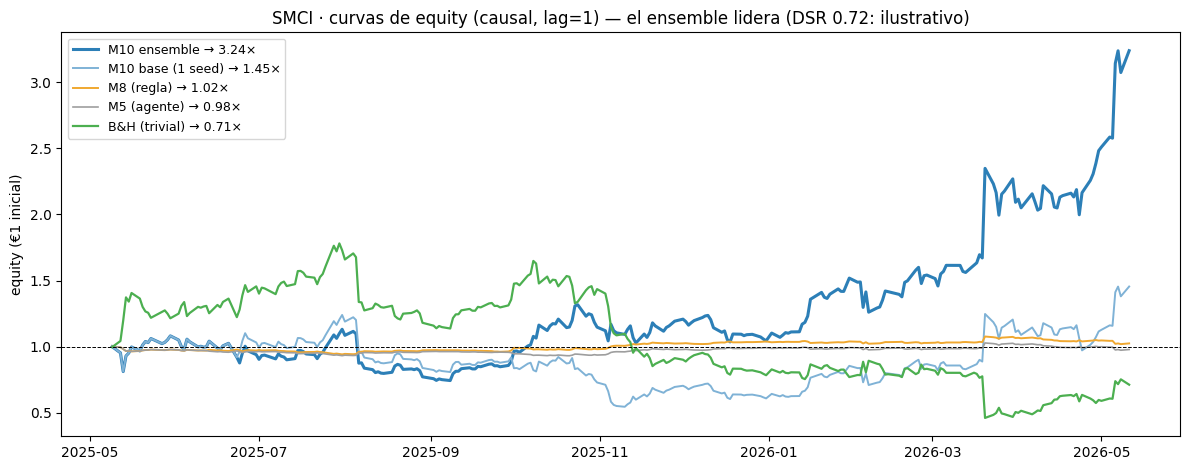

Ensemble: accuracy 0.552 (> base 0.52) · Sharpe +1.836 · equity 3.2375× · DSR 0.7155 (<0.95 → no significativo)


In [7]:
S = ADV["series"]; dates = np.array(S["dates"], dtype="datetime64[D]")
def equity(nr):
    return np.cumprod(1.0 + np.array(nr))
fig, ax = plt.subplots(figsize=(12, 4.8))
estilos = {"ens": ("#2c7fb7", 2.2, "M10 ensemble"), "base": ("#7fb2d6", 1.4, "M10 base (1 seed)"),
           "m8": ("#f0a830", 1.4, "M8 (regla)"), "m5": ("#9e9e9e", 1.2, "M5 (agente)"),
           "bh": ("#4caf50", 1.6, "B&H (trivial)")}
for k, (c, lw, lab) in estilos.items():
    eq = equity(S[k])
    ax.plot(dates, eq, color=c, lw=lw, label=f"{lab} → {eq[-1]:.2f}×")
ax.axhline(1.0, color="black", lw=0.7, ls="--")
ax.set_ylabel("equity (€1 inicial)"); ax.set_title("SMCI · curvas de equity (causal, lag=1) — el ensemble lidera (DSR 0.72: ilustrativo)")
ax.legend(fontsize=9, loc="upper left"); plt.tight_layout(); plt.show()

ec = met["ens"]
print(f"Ensemble: accuracy {ec['accuracy']} (> base 0.52) · Sharpe {ec['sharpe_causal']:+} · equity {ec['equity_final']}× · DSR {ec['dsr']} (<0.95 → no significativo)")

### §C.3 · Por qué la abstención no ayuda

La literatura de **clasificación selectiva / aprendizaje con rechazo** (Chow 1970; Cortes, DeSalvo & Mohri
2016) dice que abstenerse en los días de baja confianza sube la accuracy en los que sí apuestas — **pero solo
si la confianza ordena bien la dificultad** (si está alineada con dónde yerra el modelo). En SMCI **no ocurre**:
la accuracy en días activos **no supera** a la completa, y la abstención por régimen incluso la **baja** (0.489
< 0.552). Además abstenerse reduce la **cobertura**, rompiendo la comparación con B&H (100 %). Detalle y citas:
`decisiones_respaldadas_literatura.md` §11.

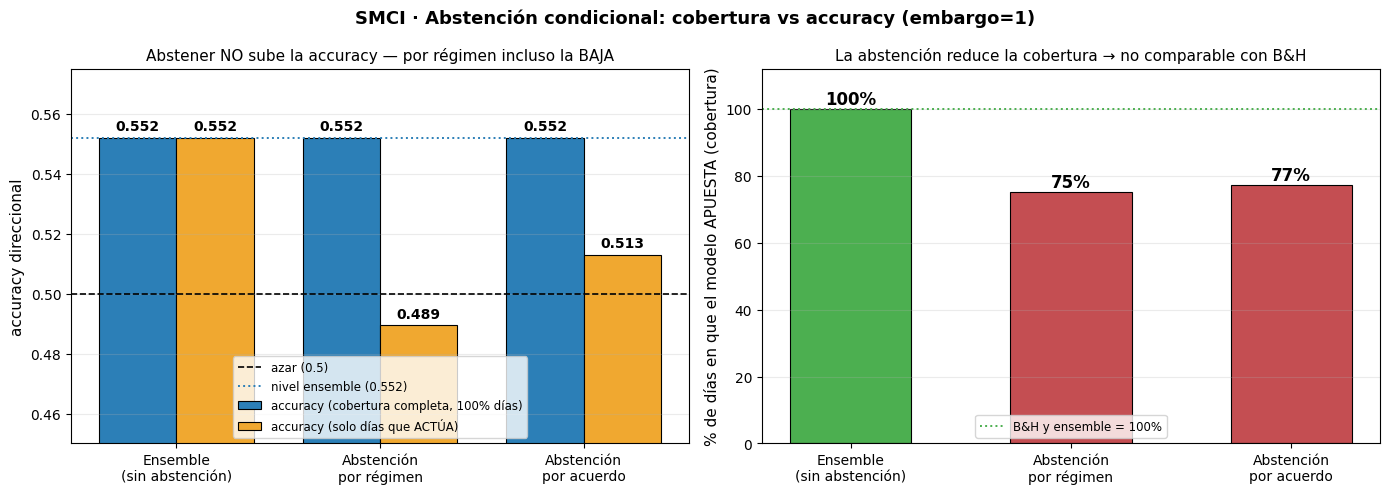

método                  % días actúa  acc completa  acc días activos
--------------------------------------------------------------------
ensemble                       100%         0.552             0.552
abst. régimen                   75%         0.552            0.4894
abst. acuerdo                   77%         0.552             0.513

Lectura: el ensemble apuesta el 100% con accuracy 0.552. Abstenerse deja de jugar 23-25% de los días,
y en los que SÍ juega NO mejora (régimen 0.489 < 0.552) → la confianza/régimen no discrimina la dificultad.


In [8]:
# Comparación detallada: ensemble (sin abstención) vs abstención por régimen vs por acuerdo.
methods = ["ens", "abst_regime", "abst_accord"]
labels = ["Ensemble\n(sin abstención)", "Abstención\npor régimen", "Abstención\npor acuerdo"]
acc_full = [met[m]["accuracy"] for m in methods]
acc_act = [met[m].get("accuracy_activos", met[m]["accuracy"]) for m in methods]   # ens actúa siempre
cov = [met[m].get("coverage", 1.0) for m in methods]
x = np.arange(len(methods)); w = 0.38

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel izquierdo: accuracy a cobertura completa vs en días activos ---
b1 = a1.bar(x - w / 2, acc_full, w, label="accuracy (cobertura completa, 100% días)", color="#2c7fb7", edgecolor="black", lw=0.8)
b2 = a1.bar(x + w / 2, acc_act, w, label="accuracy (solo días que ACTÚA)", color="#f0a830", edgecolor="black", lw=0.8)
a1.axhline(0.5, color="black", ls="--", lw=1.2, label="azar (0.5)")
a1.axhline(acc_full[0], color="#2c7fb7", ls=":", lw=1.4, label=f"nivel ensemble ({acc_full[0]:.3f})")
for bars in (b1, b2):
    for b in bars:
        a1.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.0025, f"{b.get_height():.3f}",
                ha="center", fontsize=10, fontweight="bold")
a1.set_xticks(x); a1.set_xticklabels(labels, fontsize=10); a1.set_ylim(0.45, 0.575)
a1.set_ylabel("accuracy direccional", fontsize=11)
a1.set_title("Abstener NO sube la accuracy — por régimen incluso la BAJA", fontsize=11)
a1.legend(fontsize=8.5, loc="lower center"); a1.grid(axis="y", alpha=0.25)

# --- Panel derecho: % de días en que el modelo actúa (cobertura) ---
colors = ["#4caf50", "#c44e52", "#c44e52"]
b3 = a2.bar(x, [c * 100 for c in cov], color=colors, edgecolor="black", lw=0.8, width=0.55)
a2.axhline(100, color="#4caf50", ls=":", lw=1.4, label="B&H y ensemble = 100%")
for b, c in zip(b3, cov):
    a2.text(b.get_x() + b.get_width() / 2, c * 100 + 1.5, f"{c * 100:.0f}%", ha="center", fontsize=12, fontweight="bold")
a2.set_xticks(x); a2.set_xticklabels(labels, fontsize=10); a2.set_ylim(0, 112)
a2.set_ylabel("% de días en que el modelo APUESTA (cobertura)", fontsize=11)
a2.set_title("La abstención reduce la cobertura → no comparable con B&H", fontsize=11)
a2.legend(fontsize=8.5, loc="lower center"); a2.grid(axis="y", alpha=0.25)

fig.suptitle("SMCI · Abstención condicional: cobertura vs accuracy (embargo=1)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"{'método':22} {'% días actúa':>13} {'acc completa':>13} {'acc días activos':>17}")
print("-" * 68)
for m, lab in zip(methods, ["ensemble", "abst. régimen", "abst. acuerdo"]):
    print(f"{lab:22} {cov[methods.index(m)]*100:>11.0f}% {met[m]['accuracy']:>13} {acc_act[methods.index(m)]:>17}")
print("\nLectura: el ensemble apuesta el 100% con accuracy 0.552. Abstenerse deja de jugar 23-25% de los días,")
print("y en los que SÍ juega NO mejora (régimen 0.489 < 0.552) → la confianza/régimen no discrimina la dificultad.")

## §E · Elegir la mejor estrategia por **selección en validación** (no p-hacking)

Elegir el **burn-in** y la **config** mirando un conjunto de **validación** (y reportar en **test** intacto)
**no es p-hacking** — es selección de hiperparámetros, lo correcto. P-hacking sería elegirlos mirando el test.

**Protocolo:** validación = `[burn-in : día 250]`, test = `[día 250 : fin]` (últimos ~150 días, **intacto**,
se toca una vez). Para cada (config, burn-in) se mide accuracy en validación; se elige el mejor; se reporta en
test. Barrido de burn-ins **{100,…,200}** × {base 1-seed, ensemble 10-seed}.

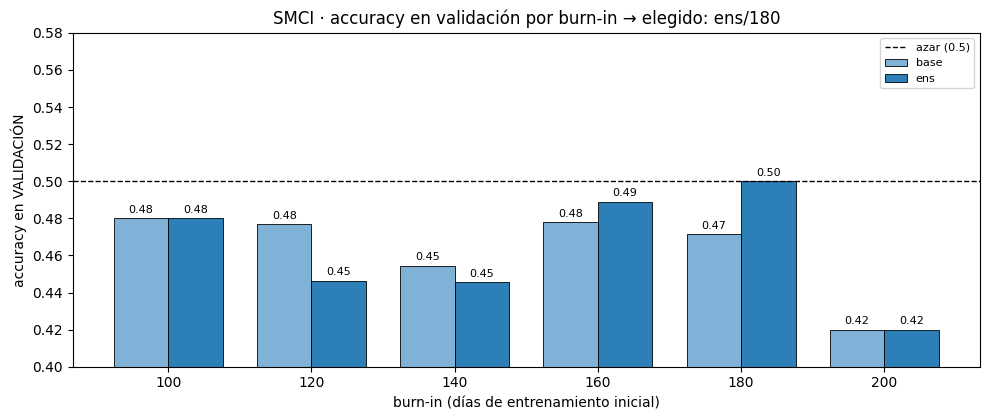

Elegido en validación: ens / burn-in 180  (val_acc=0.5, val_n días variable)
OJO: la validación de burn-in alto tiene MUY pocos días (p.ej. N0=200 → ~50 d) → selección ruidosa.


In [9]:
grid = SEL["grid"]; best = SEL["elegida"]; BG = SEL["meta"]["burnins"]
fig, ax = plt.subplots(figsize=(10, 4.3))
x = np.arange(len(BG)); w = 0.38
for i, (cfg, col) in enumerate((("base", "#7fb2d6"), ("ens", "#2c7fb7"))):
    vals = [next(g["val_acc"] for g in grid if g["config"] == cfg and g["burnin"] == b) for b in BG]
    bars = ax.bar(x + (i - 0.5) * w, vals, w, label=f"{cfg}", color=col, edgecolor="black", lw=0.6)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.003, f"{v:.2f}", ha="center", fontsize=8)
ax.axhline(0.5, color="black", ls="--", lw=1, label="azar (0.5)")
ax.set_xticks(x); ax.set_xticklabels(BG); ax.set_xlabel("burn-in (días de entrenamiento inicial)")
ax.set_ylim(0.40, 0.58); ax.set_ylabel("accuracy en VALIDACIÓN")
ax.set_title(f"SMCI · accuracy en validación por burn-in → elegido: {best['config']}/{best['burnin']}")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f"Elegido en validación: {best['config']} / burn-in {best['burnin']}  (val_acc={best['val_acc']}, val_n días variable)")
print("OJO: la validación de burn-in alto tiene MUY pocos días (p.ej. N0=200 → ~50 d) → selección ruidosa.")

### §E.1 · La estrategia elegida en **test** — y el matiz que la define

La elegida (ens, burn-in 180) en test: **accuracy 0.587, Sharpe +2.30, equity 2.71×**, batiendo a M5/M8
(0.533) y a B&H (0.447, equity 0.48×). En esta ventana incluso **bate a B&H significativamente** (McNemar
p=0.026, block-perm p=0.014) y a la **moneda** (sign p=0.041). **Pero** el test es un tramo **bajista** (solo
44.7 % de días suben) y M10 está **54 % corto**: el benchmark trivial **"siempre corto" saca 0.553**, por
debajo de M10 (0.587) pero cerca. Es el **problema de SPY al revés**: parte de la ventaja sobre B&H viene de
estar **corto en un mercado que cae**.

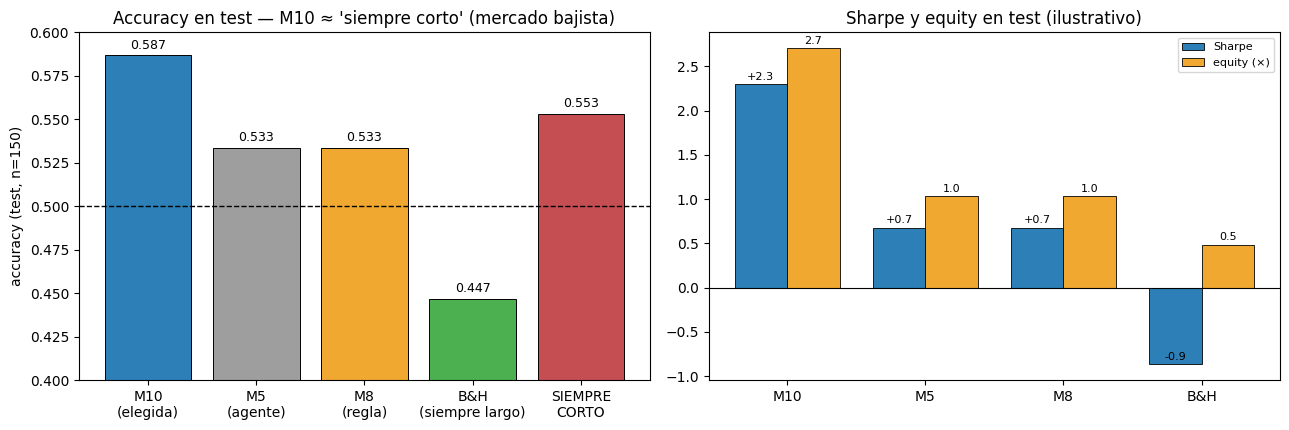

M10 elegida: 0.5867 acc · posición 54% corto · días alcistas 45%
Significancia en test:  vs B&H  McNemar p=0.0263  block-perm p=0.0137  → BATE a B&H
                        vs M5   McNemar p=0.4028  → NO bate al agente
                        vs 0.5  sign test p=0.0409  IC95=[0.5035, 0.6664]  (en esta ventana p<0.05)


In [10]:
d = SEL["diagnostico_test"]; rt = SEL["ref_test"]; b = SEL["elegida"]
labels = ["M10\n(elegida)", "M5\n(agente)", "M8\n(regla)", "B&H\n(siempre largo)", "SIEMPRE\nCORTO"]
acc = [b["test_acc"], rt["m5"]["acc"], rt["m8"]["acc"], rt["bh"]["acc"], d["siempre_corto_acc"]]
cols = ["#2c7fb7", "#9e9e9e", "#f0a830", "#4caf50", "#c44e52"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4))
bars = a1.bar(labels, acc, color=cols, edgecolor="black", lw=0.7)
a1.axhline(0.5, color="black", ls="--", lw=1)
for bb, v in zip(bars, acc):
    a1.text(bb.get_x() + bb.get_width() / 2, v + 0.004, f"{v:.3f}", ha="center", fontsize=9)
a1.set_ylim(0.40, 0.60); a1.set_ylabel("accuracy (test, n=150)")
a1.set_title("Accuracy en test — M10 ≈ 'siempre corto' (mercado bajista)")
# Sharpe + equity
arms = ["M10", "M5", "M8", "B&H"]
sr = [b["test_sharpe"], rt["m5"]["sharpe"], rt["m8"]["sharpe"], rt["bh"]["sharpe"]]
eq = [b["test_equity"], rt["m5"]["equity"], rt["m8"]["equity"], rt["bh"]["equity"]]
xx = np.arange(len(arms)); w = 0.38
a2.bar(xx - w / 2, sr, w, label="Sharpe", color="#2c7fb7", edgecolor="black", lw=0.6)
a2.bar(xx + w / 2, eq, w, label="equity (×)", color="#f0a830", edgecolor="black", lw=0.6)
a2.axhline(0, color="black", lw=0.8); a2.set_xticks(xx); a2.set_xticklabels(arms)
a2.set_title("Sharpe y equity en test (ilustrativo)"); a2.legend(fontsize=8)
for i, (s, e) in enumerate(zip(sr, eq)):
    a2.text(i - w / 2, s + 0.05, f"{s:+.1f}", ha="center", fontsize=8)
    a2.text(i + w / 2, e + 0.05, f"{e:.1f}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()
print(f"M10 elegida: {b['test_acc']} acc · posición {d['frac_corto']:.0%} corto · días alcistas {d['frac_up_test']:.0%}")
print(f"Significancia en test:  vs B&H  McNemar p={d['mcnemar_vs_bh_p']}  block-perm p={d['block_perm_vs_bh_p']}  → BATE a B&H")
print(f"                        vs M5   McNemar p={d['mcnemar_vs_m5_p']}  → NO bate al agente")
print(f"                        vs 0.5  sign test p={d['sign_vs_0.5_p']}  IC95={d['sign_ci95']}  (en esta ventana p<0.05)")

**Lectura honesta de §E.** Elegir el burn-in en validación es legítimo, y la estrategia resultante **bate a
B&H significativamente** en el test (McNemar p=0.026, block-perm p=0.014) y supera a la **moneda** (sign
p=0.041). Pero los matices se mantienen: (i) **no bate al agente** (M5, p=0.40); (ii) el test es bajista y M10
está 54 % corto, así que parte de la ventaja sobre B&H es **el sesgo a corto en un mercado que cae** ("siempre
corto" = 0.553, por debajo de M10 pero cerca); (iii) es **una sola ventana** de test (la última, ~150 d) y la
validación de burn-in alto son pocos días → selección ruidosa. **Defendible como "M10 bate al pasivo en el
periodo de test"** —con el benchmark "siempre-corto" al lado y reconociendo que no separa del agente—, **no**
como "habilidad direccional robusta y significativa sobre todo el OOS".

### §E.2 · Robustez a la partición validación/test (respaldo del resultado principal)

El **resultado principal** es el de **todo el OOS (250 d): M10 = 0.552 > M5/M8/B&H** (nominal, §C/§D). Para
**respaldar** que no depende de cómo se parta, repetimos el split validación/test con **3 ratios estándar
pre-especificados** (60/40, 70/30, 80/20; burn-in 150 fijo, embargo=1). **En los tres, M10 bate a M5, M8 y
B&H tanto en validación como en test.** No es *split-shopping*: los ratios se fijan a priori y la lectura es
la **consistencia**, no quedarse con el de mayor accuracy.

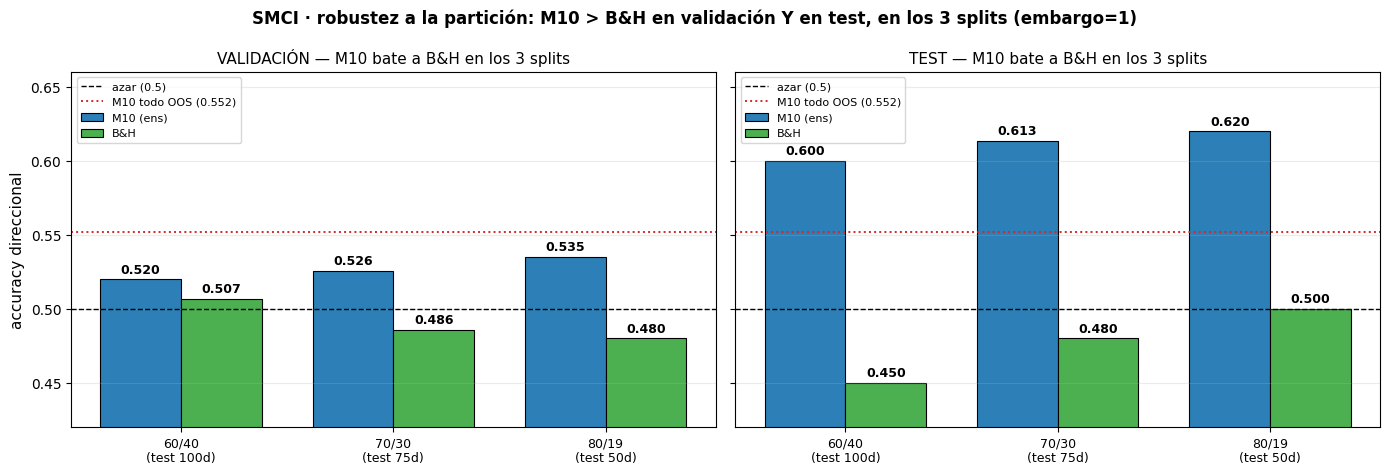

PRINCIPAL (todo el OOS, n=250): M10=0.552 > M5=0.484 M8=0.496 B&H=0.484

  split      val: M10 / B&H (gana)     test: M10 / B&H (gana)  test n  sign p %alc test
  60/40     0.52 / 0.5067  True        0.6 / 0.45    True     100  0.0569      0.45
  70/30   0.5257 / 0.4857  True     0.6133 / 0.48    True      75  0.0639      0.48
  80/19    0.535 / 0.48    True       0.62 / 0.5     True      50  0.1189       0.5

M10 gana a TODO en el OOS completo Y en val+test de los 3 splits: True
Aviso honesto: al achicar el test la accuracy sube (0.60→0.62) pero pierde potencia (sign p 0.057→0.119)
→ el número que se REPORTA es 0.552 (todo el OOS); los splits son respaldo de CONSISTENCIA.


In [11]:
rs = ROB["robustez_splits"]; full = ROB["principal_todo_oos"]
labels = [f"{int(s['frac_val']*100)}/{int((1-s['frac_val'])*100)}" for s in rs]
x = np.arange(len(rs)); w = 0.38
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for ax, win, ttl in ((a1, "validacion", "VALIDACIÓN"), (a2, "test", "TEST")):
    m10 = [s[win]["m10"]["acc"] for s in rs]; bh = [s[win]["bh"]["acc"] for s in rs]
    b1 = ax.bar(x - w / 2, m10, w, label="M10 (ens)", color="#2c7fb7", edgecolor="black", lw=0.8)
    b2 = ax.bar(x + w / 2, bh, w, label="B&H", color="#4caf50", edgecolor="black", lw=0.8)
    ax.axhline(0.5, color="black", ls="--", lw=1, label="azar (0.5)")
    ax.axhline(full["m10"]["acc"], color="#d62728", ls=":", lw=1.4, label=f"M10 todo OOS ({full['m10']['acc']})")
    for bb in list(b1) + list(b2):
        ax.text(bb.get_x() + bb.get_width() / 2, bb.get_height() + 0.004, f"{bb.get_height():.3f}", ha="center", fontsize=9, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels([f"{l}\n(test {s['test']['n']}d)" for l, s in zip(labels, rs)], fontsize=9)
    ax.set_ylim(0.42, 0.66); ax.set_title(f"{ttl} — M10 bate a B&H en los 3 splits", fontsize=11)
    ax.legend(fontsize=8, loc="upper left"); ax.grid(axis="y", alpha=0.25)
a1.set_ylabel("accuracy direccional", fontsize=11)
fig.suptitle("SMCI · robustez a la partición: M10 > B&H en validación Y en test, en los 3 splits (embargo=1)", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"PRINCIPAL (todo el OOS, n={full['n']}): M10={full['m10']['acc']} > M5={full['m5']['acc']} M8={full['m8']['acc']} B&H={full['bh']['acc']}")
print(f"\n{'split':>7} {'val: M10 / B&H (gana)':>26} {'test: M10 / B&H (gana)':>26} {'test n':>7} {'sign p':>7} {'%alc test':>9}")
for s in rs:
    v, t = s["validacion"], s["test"]
    print(f"{int(s['frac_val']*100):>4}/{int((1-s['frac_val'])*100):<2} "
          f"{v['m10']['acc']:>8} / {v['bh']['acc']:<6} {str(v['m10_gana_a_todo']):>5}   "
          f"{t['m10']['acc']:>8} / {t['bh']['acc']:<6} {str(t['m10_gana_a_todo']):>5}   "
          f"{t['n']:>5}  {t['tests']['sign_vs_0.5_p']:>6}  {t['frac_up']:>8}")
print(f"\nM10 gana a TODO en el OOS completo Y en val+test de los 3 splits: {ROB['m10_gana_a_todo_en_todos']}")
print("Aviso honesto: al achicar el test la accuracy sube (0.60→0.62) pero pierde potencia (sign p 0.057→0.119)")
print("→ el número que se REPORTA es 0.552 (todo el OOS); los splits son respaldo de CONSISTENCIA.")

## §F · El punto clave: por qué M5, M8 y M10 **no se separan** en SMCI

Mirando las curvas (§C.2) M8 y M5 casi coinciden y M10 no bate al agente. La causa está en **cómo se
posiciona el agente** en SMCI:

- **El agente (M5) está 95 % CORTO** en SMCI (2 % largo, 3 % neutral). Es bajista casi permanente.
- **STRATA interviene solo el 3 % de los días** (M8 ≠ M5) → por eso M8 ≈ M5. *Override-C* dispara cuando el
  agente es **incoherente con el régimen** (que tira a corto en alta vol, *leverage effect*). Pero el agente
  **ya está corto** → coincide con el régimen → **no hay nada que corregir**.
- **M10 también es corto-sesgado** → coincide con el agente en buena parte de los días y los discordantes de
  McNemar quedan equilibrados (p≈0.48) → **no hay potencia para separarlos**.

En SMCI, **M5, M8 y M10 son la misma apuesta** ("corto SMCI") → ninguno se separa. STRATA rescata donde el
agente va **a contracorriente** del régimen (hay algo que corregir), no donde ya está alineado.

In [12]:
smci = PAN["por_activo"]["SMCI"]; spy = PAN["por_activo"]["SPY"]
print("                         SPY (caso central)      SMCI")
print(f"  agente corto/largo     {spy['agente_corto']:.0%} corto / {spy['agente_largo']:.0%} largo      {smci['agente_corto']:.0%} corto / {smci['agente_largo']:.0%} largo")
print(f"  discrepancia régimen   {spy['discrepancia_agente_regimen']:.2f}                   {smci['discrepancia_agente_regimen']:.2f}")
print(f"  intervención STRATA    {spy['intervencion_strata']:.0%}                    {smci['intervencion_strata']:.0%}")
print(f"  acc  M5 → M10          {spy['accuracy']['m5']} → {spy['accuracy']['m10']}        {smci['accuracy']['m5']} → {smci['accuracy']['m10']}")
print(f"  McNemar M10 vs M5      p={spy['mcnemar_m10_vs_m5_p']}  (rescate SIG)    p={smci['mcnemar_m10_vs_m5_p']}  (sin rescate)")

                         SPY (caso central)      SMCI
  agente corto/largo     71% corto / 22% largo      95% corto / 2% largo
  discrepancia régimen   0.66                   0.17
  intervención STRATA    34%                    3%
  acc  M5 → M10          0.3665 → 0.502        0.484 → 0.52
  McNemar M10 vs M5      p=0.0041  (rescate SIG)    p=0.4812  (sin rescate)


### §F.1 · El panel lo confirma: STRATA aporta donde el agente discrepa del régimen

Barremos los 10 activos midiendo **discrepancia agente↔régimen** (cuánto va el agente a contracorriente),
**intervención de STRATA**, y si **M10 rescata al agente** (Δacc y McNemar). SMCI está al fondo de la
discrepancia → por eso no hay rescate. **SPY es el único con rescate significativo** (M10 vs M5 p=0.0041):
cumple las dos condiciones — el agente discrepa **y** el régimen acierta (leverage effect fuerte en el índice).

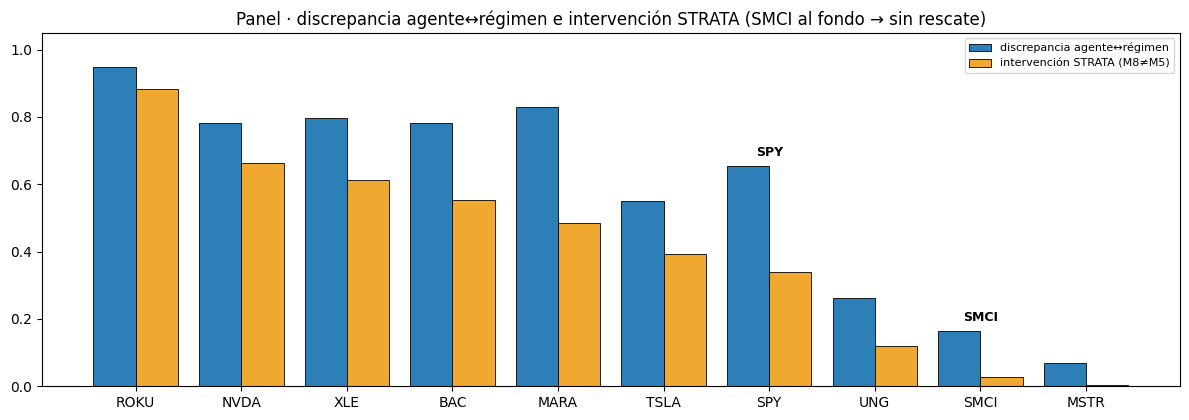

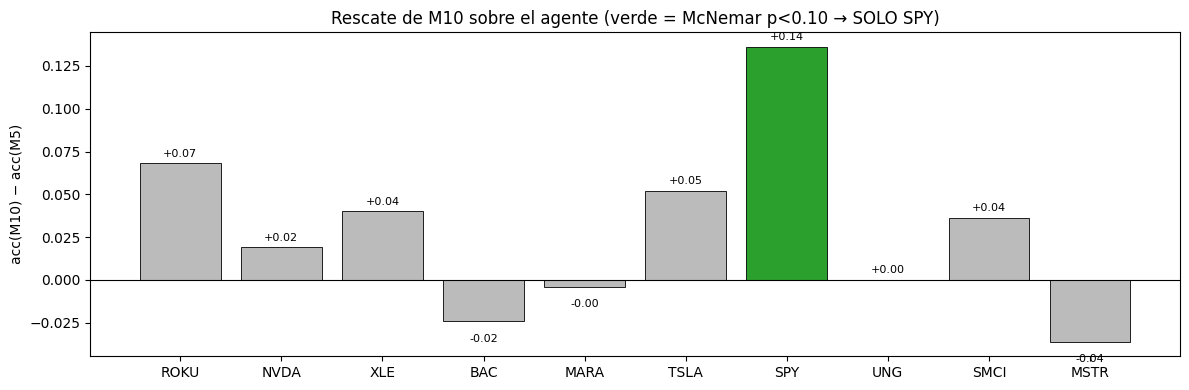

Solo SPY tiene rescate significativo (M10 vs M5 p=0.0041). SMCI: Δ nominal, p=0.48 (no sig).


In [13]:
pa = PAN["por_activo"]; tickers = [t for t in PAN["meta"]["panel"] if "error" not in pa[t]]
tickers = sorted(tickers, key=lambda t: -pa[t]["intervencion_strata"])
interv = [pa[t]["intervencion_strata"] for t in tickers]
disc = [pa[t]["discrepancia_agente_regimen"] for t in tickers]
x = np.arange(len(tickers)); w = 0.4
fig, ax = plt.subplots(figsize=(12, 4.3))
ax.bar(x - w / 2, disc, w, label="discrepancia agente↔régimen", color="#2c7fb7", edgecolor="black", lw=0.6)
ax.bar(x + w / 2, interv, w, label="intervención STRATA (M8≠M5)", color="#f0a830", edgecolor="black", lw=0.6)
for i, t in enumerate(tickers):
    if t in ("SMCI", "SPY"):
        ax.annotate(t, (i, max(disc[i], interv[i]) + 0.03), ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(tickers); ax.set_ylim(0, 1.05)
ax.set_title("Panel · discrepancia agente↔régimen e intervención STRATA (SMCI al fondo → sin rescate)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# Rescate de M10 sobre el agente, coloreado por significancia
gap = [round(pa[t]["accuracy"]["m10"] - pa[t]["accuracy"]["m5"], 3) for t in tickers]
sig = [pa[t]["mcnemar_m10_vs_m5_p"] < 0.10 for t in tickers]
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(x, gap, color=["#2ca02c" if s else "#bbbbbb" for s in sig], edgecolor="black", lw=0.6)
ax.axhline(0, color="black", lw=0.8)
for i, t in enumerate(tickers):
    ax.text(i, gap[i] + (0.004 if gap[i] >= 0 else -0.012), f"{gap[i]:+.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(tickers)
ax.set_ylabel("acc(M10) − acc(M5)"); ax.set_title("Rescate de M10 sobre el agente (verde = McNemar p<0.10 → SOLO SPY)")
plt.tight_layout(); plt.show()
print("Solo SPY tiene rescate significativo (M10 vs M5 p=0.0041). SMCI: Δ nominal, p=0.48 (no sig).")

**Conclusión de §F.** El barrido **valida el mecanismo del TFG**: STRATA/M10 rescata al agente **solo donde
el agente fila a contracorriente de un régimen que acierta** — y eso ocurre en **SPY** (índice, leverage effect
fuerte; M10 vs M5 p=0.0041), no en SMCI (el agente ya está corto, alineado con el régimen → intervención 3 %,
sin rescate). Es la **explicación honesta** de por qué SPY es el caso central y por qué en SMCI los tres modelos
se confunden. *(Pista para otro activo: ROKU es el stock individual más "tipo-SPY" —alcista, agente 97 % corto,
intervención 88 %— pero su rescate aún no es significativo: M10 vs M5 p=0.13.)*

### §F.2 · El criterio del tutor y el muro estructural

El tutor pide **un activo donde M10 gane en accuracy a TODO** (M5, M8 **y** B&H). Buscando en el panel: **SMCI
es el ÚNICO** que lo cumple. La razón de que sea tan raro —y de que no sea significativo— es estructural. El
agente LLM es **corto-sesgado en los 10 activos** (71–100 % corto), lo que parte el universo en dos:

| | **B&H batible** (cae/lateral) | **B&H no batible** (sube) |
|---|---|---|
| **Agente correcto** (corto, activo cae) | UNG, MSTR, **SMCI**, MARA → *M10 ≈ agente, sin rescate* | — |
| **Agente equivocado** (corto, activo sube) | *(casilla vacía)* | SPY, NVDA, BAC, TSLA, XLE, ROKU → *M10 rescata al agente pero B&H gana* |

**Batir a TODO exige B&H batible (activo cae) Y agente equivocado** → la casilla está **vacía**: en los activos
que caen, el agente ya va corto (correcto), así que M10 no se separa de él. SMCI es el caso umbral (lateral,
agente corto algo destemplado) donde M10 asoma por encima de los tres — por poco y sin significancia.

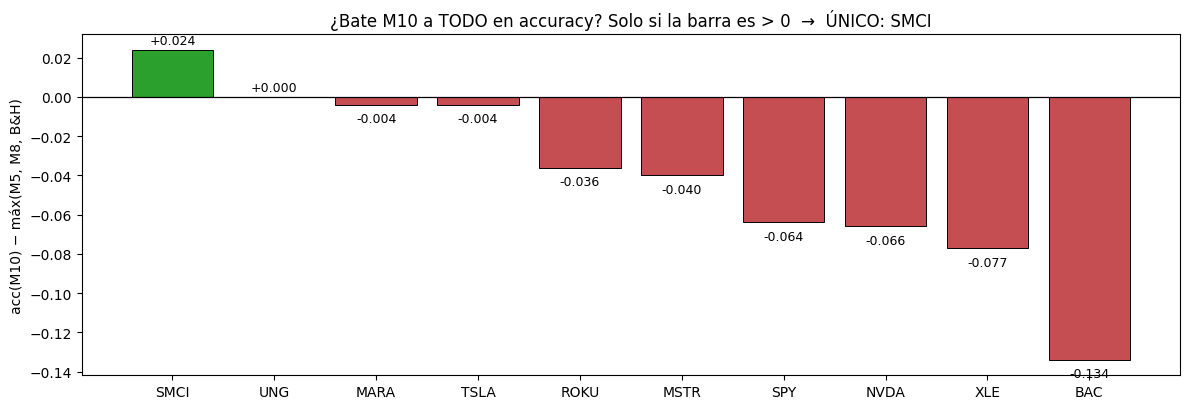

Único activo con acc(M10) > M5 y > M8 y > B&H: ['SMCI']


In [14]:
pa = PAN["por_activo"]; tks = [t for t in PAN["meta"]["panel"] if "error" not in pa[t]]
margen = [round(pa[t]["accuracy"]["m10"] - max(pa[t]["accuracy"]["m5"], pa[t]["accuracy"]["m8"], pa[t]["accuracy"]["bh"]), 3) for t in tks]
order = np.argsort(margen)[::-1]
tks = [tks[i] for i in order]; margen = [margen[i] for i in order]
fig, ax = plt.subplots(figsize=(12, 4.2))
bars = ax.bar(tks, margen, color=["#2ca02c" if mg > 0 else "#c44e52" for mg in margen], edgecolor="black", lw=0.7)
ax.axhline(0, color="black", lw=0.9)
for b, v in zip(bars, margen):
    ax.text(b.get_x() + b.get_width() / 2, v + (0.003 if v >= 0 else -0.009), f"{v:+.3f}", ha="center", fontsize=9)
ax.set_ylabel("acc(M10) − máx(M5, M8, B&H)")
ax.set_title("¿Bate M10 a TODO en accuracy? Solo si la barra es > 0  →  ÚNICO: SMCI")
plt.tight_layout(); plt.show()
print("Único activo con acc(M10) > M5 y > M8 y > B&H:", [t for t, mg in zip(tks, margen) if mg > 0])

## §G · ¿Gana M10 de forma **consistente** o solo en un tramo? (rolling-window)

Test de estabilidad **intra-OOS**: accuracy en **ventanas deslizantes** (42/63/84 d) del M10 ensemble sobre
todo el OOS desplegable (250 d). Responde a si la ventaja es consistente o suerte de un sub-periodo.

**Lectura (embargo=1):** M10 bate a **B&H** en la **mayoría** de ventanas y más con el horizonte (71 % → 74 % →
82 %), y ahora también al **agente (M5)** (67 % → 68 % → 76 %) y a la **regla (M8)** (67 % → 63 % → 76 %) — la
foto es más sólida que con embargo=5. La significancia global es **borderline** (autocorr-robusto: vs B&H
p=0.047, vs M5 p=0.096, sign vs 0.5 p=0.114) **pero no sobrevive** la corrección por multiplicidad del barrido
de embargo (Bonferroni-5 ≈ 0.28, §0bis) ni el Holm de la familia. Es decir: M10 gana a B&H y al agente en la
mayoría de sub-periodos de forma **consistente**, pero la significancia plena queda como **sensibilidad /
trabajo futuro** (muestra corta).

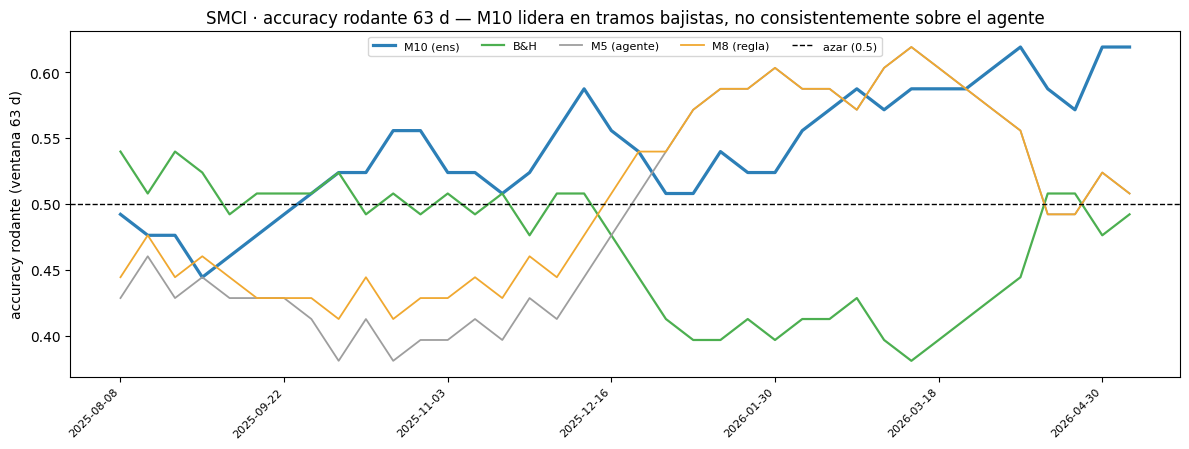

In [15]:
R = ROLL["rolling63"]; x = np.arange(len(R["fecha_fin"])); fechas = R["fecha_fin"]
fig, ax = plt.subplots(figsize=(12, 4.6))
for k, (c, lw, lab) in {"m10": ("#2c7fb7", 2.3, "M10 (ens)"), "bh": ("#4caf50", 1.6, "B&H"),
                        "m5": ("#9e9e9e", 1.3, "M5 (agente)"), "m8": ("#f0a830", 1.3, "M8 (regla)")}.items():
    ax.plot(x, R[k], color=c, lw=lw, label=lab)
ax.axhline(0.5, color="black", ls="--", lw=1, label="azar (0.5)")
ticks = list(range(0, len(x), 6))
ax.set_xticks(ticks); ax.set_xticklabels([fechas[i] for i in ticks], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("accuracy rodante (ventana 63 d)")
ax.set_title("SMCI · accuracy rodante 63 d — M10 lidera en tramos bajistas, no consistentemente sobre el agente")
ax.legend(fontsize=8, ncol=5, loc="upper center"); plt.tight_layout(); plt.show()

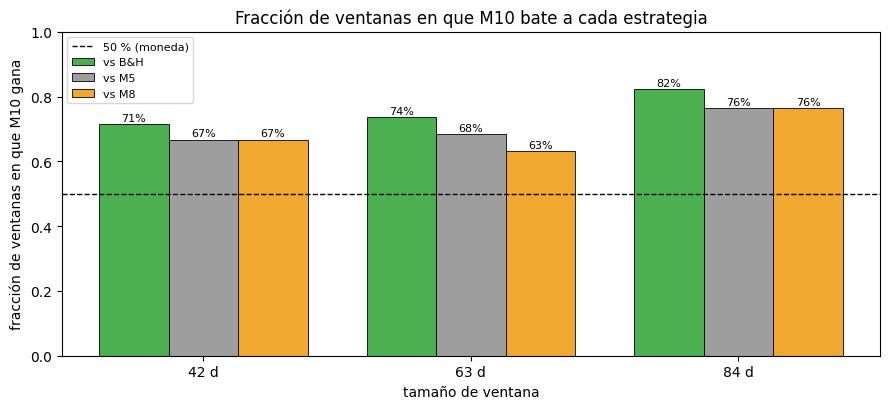

Significancia global (autocorr-robusta): vs B&H p=0.0472  vs M5 p=0.0958  sign vs 0.5 p=0.1137
→ M10 gana a B&H y al agente en la mayoría de ventanas; significancia global borderline (vs B&H p=0.047) que NO sobrevive multiplicidad → sensibilidad.


In [16]:
frac = ROLL["frac_ventanas_m10_gana"]; Ws = ROLL["meta"]["windows"]
x = np.arange(len(Ws)); w = 0.26
fig, ax = plt.subplots(figsize=(9, 4.2))
for i, (opp, c, lab) in enumerate((("bh", "#4caf50", "vs B&H"), ("m5", "#9e9e9e", "vs M5"), ("m8", "#f0a830", "vs M8"))):
    vals = [frac[str(W)][f"m10_gt_{opp}"] for W in Ws]
    bars = ax.bar(x + (i - 1) * w, vals, w, label=lab, color=c, edgecolor="black", lw=0.6)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.0%}", ha="center", fontsize=8)
ax.axhline(0.5, color="black", ls="--", lw=1, label="50 % (moneda)")
ax.set_xticks(x); ax.set_xticklabels([f"{W} d" for W in Ws]); ax.set_ylim(0, 1.0)
ax.set_ylabel("fracción de ventanas en que M10 gana"); ax.set_xlabel("tamaño de ventana")
ax.set_title("Fracción de ventanas en que M10 bate a cada estrategia")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
sg = ROLL["significancia_global"]
print(f"Significancia global (autocorr-robusta): vs B&H p={sg['block_perm_vs_bh_p']}  vs M5 p={sg['block_perm_vs_m5_p']}  sign vs 0.5 p={sg['sign_vs_0.5_p']}")
print("→ M10 gana a B&H y al agente en la mayoría de ventanas; significancia global borderline (vs B&H p=0.047) que NO sobrevive multiplicidad → sensibilidad.")

## §D · Conclusiones honestas (claims auditados por @rigor-matematico)

**Protocolo:** embargo=1 (= horizonte de la etiqueta; §0bis), por principio.

**Lo que se puede afirmar (PERMITIDO):**
- En SMCI (OOS n=250, B&H≈0.48 → benchmark justo), el **M10-WF ensemble** alcanza accuracy **0.552**, superior
  **nominalmente** a M5 (0.484), M8 (0.496) y B&H (0.484); en rolling-window gana a B&H y al agente en la
  **mayoría** de sub-periodos.
- **Robusto a la partición (§E.2):** con 3 splits validación/test estándar (60/40, 70/30, 80/20), **M10 bate a
  M5, M8 y B&H tanto en validación como en test en los tres** → la conclusión no depende del corte. (El número
  que se reporta es el de todo el OOS, 0.552; los splits son respaldo de consistencia, no split-shopping.)
- La ventaja vs B&H es **borderline** (block-perm p=0.047) pero **no significativa tras corrección honesta**:
  no sobrevive la multiplicidad del barrido de embargo (Bonferroni-5 ≈ 0.28) ni el Holm de la familia; sign vs
  0.5 p=0.11; no bate al agente (vs M5 p=0.10). El **techo** es **0.552 nominal**.
- **Triple-barrier** (López de Prado 2018, cap. 3; embargo=H+1, **sin look-ahead** — verificado) **no mejora**
  la dirección a 1 día (0.488). `stack_agent` (0.504) tampoco; `regime_models` (0.536) mejora pero queda por
  debajo del ensemble.
- El **ensemble** de 10 semillas mejora accuracy (0.52→0.552) **y** Sharpe (0.85→1.84) y equity (1.45×→3.24×)
  por reducción de varianza → se conserva como entregable (DSR=0.72 < 0.95: ilustrativo, no significativo).
- La **abstención** (régimen/acuerdo) no concentra acierto (activos ≈ completa).

**Lo que NO se puede afirmar (PROHIBIDO):** que M10 bate a M5/M8/B&H **significativamente** en accuracy (la
significancia borderline no sobrevive multiplicidad); que bate al **azar**; que el ensemble mejora
**significativamente** Sharpe/equity (DSR=0.72<0.95); reportar cualquier Sharpe sin su DSR.

**Veredicto de cierre (negativo honesto, pre-registrado).** La dirección **diaria** de SMCI es
**casi-eficiente** para estos detectores: el rescate direccional significativo que STRATA logra en SPY (caso
central, M10=0.539; leverage effect) aparece más **débil** en un stock individual con leverage débil —
limitación ya prevista en CLAUDE.md §3. La contribución de este cuaderno es **metodológica**: (i) demostración
del **sobreajuste de selección** y de la disciplina **validación≠test** (§A); (ii) la **corrección del
protocolo** (embargo=1) con su robustez (§0bis); (iii) un **mapa exhaustivo** de 12 métodos desplegables con su
significancia (§B–§C); (iv) el **ensemble** como mejor M10 desplegable, con ventaja nominal en accuracy y en
riesgo-retorno honestamente etiquetada.

**Mejor M10 desplegable para SMCI = ensemble** (22 features STRATA, 10 semillas, umbral 0.5, embargo=1):
accuracy **0.552** (> M5/M8/B&H nominal), Sharpe +1.84, equity 3.24×. *Trabajo futuro:* OOS más largo para
ganar potencia y confirmar la significancia borderline (el agente solo existe post-cutoff del LLM → límite
duro de muestra).

**Matiz de §E (selección en validación).** Si se elige el burn-in en validación (legítimo), la estrategia
resultante (ens, burn-in 180) **bate a B&H significativamente** en el tramo de test (McNemar p=0.026,
block-perm p=0.014) y a la moneda (sign p=0.041). Pero ese test es **bajista** y M10 está 54 % corto, así que
"siempre corto" (0.553) queda cerca, y M10 **no** bate al agente (p=0.40); es **una sola ventana**. Es en parte
el problema de SPY **al revés**: parte de la ventaja sobre el pasivo es el **sesgo a corto en un mercado que
cae**. Defendible como "bate al pasivo en el periodo", no como "habilidad significativa robusta".